# Phase 9 — Intervention Optimization (Synthetic Data)
**InterveneAI · who gets what, under a budget — scored against ground truth.**

Decision point: snapshot 2018-06-01 (38,376 customers). Per customer x
intervention, actual T-learner outputs give P(Y|T=0), P(Y|T=arm), uplift;
assumed flat costs and the customer's own historical AOV give expected
revenue (uplift x AOV) and profit (revenue − cost). Three rankings compete
for the same budget — purchase probability (A), uplift (B), expected profit
(C) — and each plan is scored twice: what the model believes and what the
simulation oracle says. Nothing here is proven in a real business experiment;
all profits are synthetic.

## Economics used (assumptions, not measurements)
- Cost: coupon 5, free_delivery 8, loyalty_points 3 BRL — flat, assumed.
- Expected revenue per treated customer = predicted uplift x that
  customer's avg_order_value_180d (a proxy: future baskets are assumed to
  look like past baskets; price and basket-size effects of the intervention
  itself are ignored).
- Expected profit = revenue − cost. Greedy allocation: each customer gets at
  most their best-profit arm; walk the ranking while cost fits the budget.
  Strategy C additionally treats only model-profit-positive rows; A and B
  may select money-losers (counted honestly).
- Oracle scoring: TRUE_TAU[arm] x heterogeneity x AOV − cost, from the
  documented DGP — the honest judge the planner never sees in reality.

In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = None
for cand in [Path("data/synthetic/optimization_summary.json"),
             Path("../data/synthetic/optimization_summary.json")]:
    if cand.exists():
        ROOT = cand.resolve().parents[2]
        break
assert ROOT is not None, "optimization outputs not found"
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

def find(base):
    p = ROOT / base
    assert p.exists(), p
    return p

import joblib
from src.optimization.intervention_optimizer import (
    ARM_NAMES, DECISION_SNAPSHOT, STRATEGIES, build_prediction_frame,
    load_arm_models, optimize)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

with open(find("data/synthetic/optimization_summary.json")) as f:
    saved = json.load(f)
recs = pd.read_parquet(find("data/synthetic/optimization_recommendations.parquet"))
print("decision snapshot:", saved["decision_snapshot"],
      "| budgets:", list(saved["budgets"]))
print("recommendation rows:", len(recs), "| strategies:",
      sorted(recs["strategy"].unique()))
print("output columns:", list(recs.columns))

decision snapshot: 2018-06-01 | budgets: ['5000.0', '20000.0', '50000.0', '150000.0']
recommendation rows: 16693 | strategies: ['A_purchase_prob', 'B_uplift', 'C_profit']
output columns: ['customer_unique_id', 'recommended_intervention', 'expected_incremental_revenue', 'expected_incremental_cost', 'expected_incremental_profit', 'oracle_profit', 'strategy']


## 1. Verify saved plans by recomputation
Reload arm models, rebuild the prediction frame for the decision snapshot,
re-run the greedy optimizer at the primary budget, and assert the saved
recommendations and summary match exactly.

In [2]:
from src.causal.uplift_model import load_uplift_frame

models = load_arm_models()
df = load_uplift_frame()
snap = df[df["snapshot_date"] == DECISION_SNAPSHOT].copy()
_, best = build_prediction_frame(snap, models)
print("customers:", len(best), "| profit-positive (model):",
      int((best["exp_profit"] > 0).sum()))

BUDGET = 20000.0
for name, (rank_by, filt) in STRATEGIES.items():
    plan = optimize(best, BUDGET, rank_by, filt)
    got = saved["budgets"][str(BUDGET)][name]
    assert len(plan) == got["n_treated"], name
    assert abs(plan["expected_incremental_cost"].sum() - got["spend"]) < 1e-6
    assert abs(plan["expected_incremental_profit"].sum()
               - got["model_expected_profit"]) < 1e-6
    assert abs(plan["oracle_profit"].sum() - got["oracle_profit"]) < 1e-6
    kept = recs[recs["strategy"] == name].drop(columns=["strategy"]).reset_index(drop=True)
    mine = plan.reset_index(drop=True)
    pd.testing.assert_frame_equal(kept, mine, check_dtype=False)
print("all strategies at primary budget reproduce saved files exactly")
print("model bundles used: coupon (Phase 8) + free_delivery + loyalty_points")

customers: 38376 | profit-positive (model): 15909
all strategies at primary budget reproduce saved files exactly
model bundles used: coupon (Phase 8) + free_delivery + loyalty_points


## 2. What the planner believes (model-expected view)
Per-customer best-arm economics at the decision snapshot, and each
strategy's plan totals at the primary budget — before the oracle judges.

best-arm exp_profit distribution (BRL per customer):
count   38376.000000
mean       -0.142072
std        11.035604
min       -71.037723
25%        -4.406115
50%        -1.777267
75%         3.342399
max       529.284735


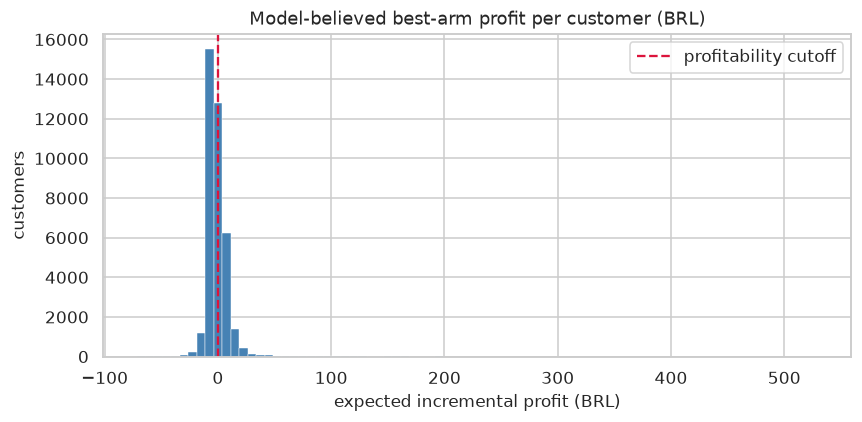

       strategy    n  spend  model_profit                                                           mix
A_purchase_prob 4493  20000        -21638 {'coupon': 3168, 'free_delivery': 37, 'loyalty_points': 1288}
       B_uplift 6170  19999         41955 {'coupon': 312, 'free_delivery': 173, 'loyalty_points': 5685}
       C_profit 6030  20000         86308  {'coupon': 730, 'free_delivery': 90, 'loyalty_points': 5210}


In [3]:
print("best-arm exp_profit distribution (BRL per customer):")
print(best["exp_profit"].describe().to_string())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(best["exp_profit"], bins=80, color="steelblue", edgecolor="white",
        linewidth=0.3)
ax.axvline(0, color="crimson", linestyle="--", label="profitability cutoff")
ax.set_title("Model-believed best-arm profit per customer (BRL)")
ax.set_xlabel("expected incremental profit (BRL)")
ax.set_ylabel("customers")
ax.legend()
plt.tight_layout()
plt.show()

rows = []
for name in ["A_purchase_prob", "B_uplift", "C_profit"]:
    s = saved["budgets"][str(BUDGET)][name]
    rows.append([name, s["n_treated"], round(s["spend"]),
                 round(s["model_expected_profit"]), str(s["mix"])])
print(pd.DataFrame(rows, columns=["strategy", "n", "spend",
      "model_profit", "mix"]).to_string(index=False))

## 3. Strategy comparison — model belief vs oracle truth
Same plans, two judges. The oracle column uses simulation ground truth the
planner cannot see in reality; its verdict is the honest one.

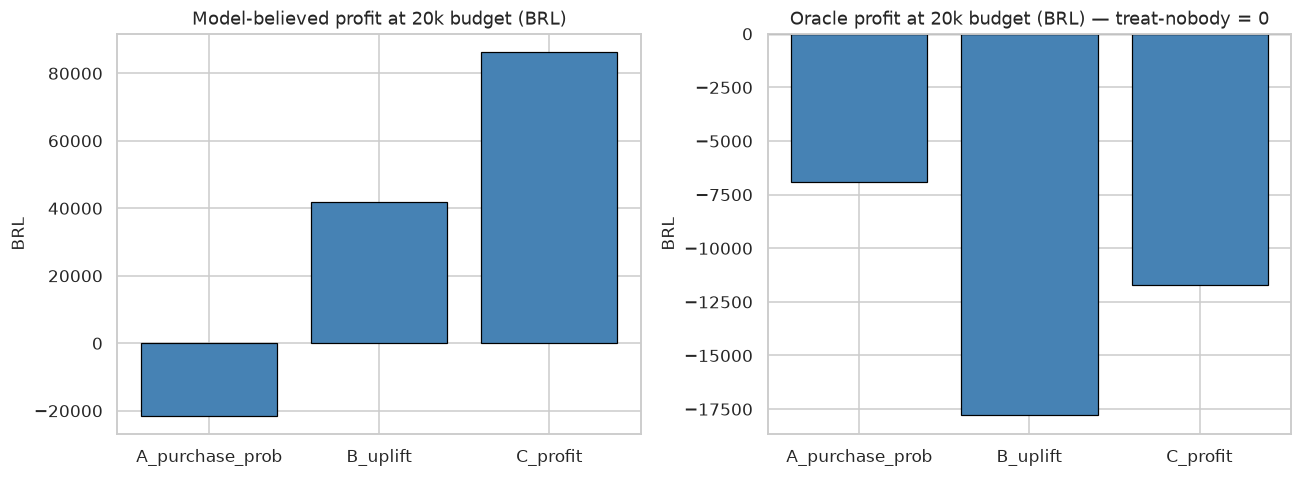

oracle profit by budget x strategy (BRL):
          A_purchase_prob  B_uplift  C_profit
5000.0               2009     -4217      -761
20000.0             -6906    -17791    -11703
50000.0            -28541    -44229    -37388
150000.0           -94846    -94846    -37633

model-believed profit by budget x strategy (BRL):
          A_purchase_prob  B_uplift  C_profit
5000.0              -6246     24137     42043
20000.0            -21637     41955     86308
50000.0            -76621     78370    112490
150000.0            -5452     -5452    112492


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
names = ["A_purchase_prob", "B_uplift", "C_profit"]
model_p = [saved["budgets"][str(BUDGET)][n]["model_expected_profit"] for n in names]
oracle_p = [saved["budgets"][str(BUDGET)][n]["oracle_profit"] for n in names]
axes[0].bar(names, model_p, color="steelblue", edgecolor="black", linewidth=0.8)
axes[0].set_title("Model-believed profit at 20k budget (BRL)")
axes[0].set_ylabel("BRL")
axes[1].bar(names, oracle_p, color=["steelblue", "steelblue", "steelblue"],
            edgecolor="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Oracle profit at 20k budget (BRL) — treat-nobody = 0")
axes[1].set_ylabel("BRL")
plt.tight_layout()
plt.show()

print("oracle profit by budget x strategy (BRL):")
tbl = pd.DataFrame(
    {b: {n: int(saved["budgets"][b][n]["oracle_profit"]) for n in names}
     for b in saved["budgets"]}).T
print(tbl.to_string())
print()
print("model-believed profit by budget x strategy (BRL):")
tbl2 = pd.DataFrame(
    {b: {n: int(saved["budgets"][b][n]["model_expected_profit"]) for n in names}
     for b in saved["budgets"]}).T
print(tbl2.to_string())

## 4. Why targeting purchase probability fails
Strategy A ranks by P(Y|T=0): compare who it treats against strategy C —
control-model purchase probability and oracle profit per treated customer.
Sure things should dominate A's plan if the criticism holds.

In [5]:
snap_idx = snap.set_index("customer_unique_id")
for name in ["A_purchase_prob", "C_profit"]:
    ids = recs[recs["strategy"] == name]["customer_unique_id"]
    part = snap_idx.loc[ids]
    plan = recs[recs["strategy"] == name]
    print(name, ": treated =", len(plan),
          "| mean P(Y|T=0) of treated =",
          round(float(best.set_index("customer_unique_id").loc[ids]["p_control"].mean()), 4),
          "| oracle profit per treated =",
          round(float(plan["oracle_profit"].sum() / len(plan)), 2), "BRL")
print()
print("population mean P(Y|T=0):",
      round(float(best["p_control"].mean()), 4))

A_purchase_prob : treated = 4493 | mean P(Y|T=0) of treated = 0.5799 | oracle profit per treated = -1.54 BRL
C_profit : treated = 6030 | mean P(Y|T=0) of treated = 0.4118 | oracle profit per treated = -1.94 BRL

population mean P(Y|T=0): 0.4711


## Key findings (synthetic economics — no real-experiment claims)

1. **Under the assumed economics, the campaign loses money.** True effects
   (≤0.9pp) times typical baskets (≈158 BRL) yield at most ~1.4 BRL revenue
   against 3–8 BRL costs, so oracle profit is negative at every budget for
   every strategy (e.g. −6.9k/−17.8k/−11.7k at 20k budget) — except one
   small-budget cell (A at 5k: +2.0k). The oracle-optimal policy is
   treat-nobody (profit 0), which beats all three strategies everywhere.
2. **Model-believed profits are fantasy.** Strategy C expects +86k at 20k
   budget while the oracle says −11.7k: miscalibrated uplift magnitudes
   (Phase 8) inflate expected revenue ~8x. Optimizing miscalibrated scores
   manufactures confidence, not profit — the oracle gap is the finding.
3. **Model-based strategy ranking does not transfer.** By its own lights C
   dominates at every budget (C > B > A throughout); by the oracle at 20k
   the order is A > C > B. Selecting rules on model-expected profit would
   pick confidently and wrongly.
4. **Purchase-probability targeting wastes budget structurally.** A's
   treated average P(Y|T=0) = 0.58 vs 0.47 population (C: 0.41): it buys
   sure-things who purchase anyway, and its model-expected profit is
   negative at every budget (−21.6k at 20k). Never target raw purchase
   probability — confirmed on actual outputs.
5. **Mechanics behave as specified.** Greedy allocation respects every
   budget exactly (spend ≤ budget; A and B converge to the identical
   saturate-everyone plan at 150k); C treats only model-positive rows
   (15,909 eligible of 38,376); all saved plans reproduce exactly.


## Limitations
- Revenue proxy (historical AOV), flat assumed costs, no basket/price
  effects, no interference or carryover, single snapshot, greedy (not
  optimal) knapsack — each a simplification documented, not defended.
- Uplift scores are miscalibrated (Phase 8), so model-expected profits are
  unreliable by construction; the oracle exists only in simulation.
- Strategy differences here reflect assumed economics; nothing transfers
  to real customers without a real randomized experiment.